## Setup

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from lordcapulet.data_structures import DataBank
from lordcapulet.simulator.search_simulator import SearchSimulator

## Configuration

In [7]:
# Edit these parameters
CONFIG = {
    # "ground_truth_json": "./UO2_scan_data_extractor_so_n_converted.json",
    "ground_truth_json": "./FeO_scan_data_extractor_redone.json",
    "M_initial": 30,              # Starting pool size
    "N_proposals": 50,            # Proposals per iteration
    "distance_threshold": 2.4,   # Success threshold
    "random_seed": 42,
    "proposal_mode": "random",   # 'random' or 'random_so_n'
    "randomize_oxidation": True,
}

## Load Ground Truth

In [8]:
ground_truth = DataBank.from_json(CONFIG["ground_truth_json"], only_converged=True)

print(f"Ground Truth DataBank:")
print(f"  Total states: {len(ground_truth)}")
print(f"  Atoms: {ground_truth.atom_ids}")
print(f"  Energy range: [{ground_truth.energies.min():.2f}, {ground_truth.energies.max():.2f}] eV")

Ground Truth DataBank:
  Total states: 419
  Atoms: ['1', '2']
  Energy range: [-10012.64, -10003.57] eV


## Initialize Simulator

**Run this once** to create the simulator and random starting pool.

In [9]:
simulator = SearchSimulator(
    ground_truth_databank=ground_truth,
    distance_threshold=CONFIG["distance_threshold"]
)

simulator.initialize_from_random(
    M=CONFIG["M_initial"],
    seed=CONFIG["random_seed"]
)

print(f"\nInitialized with {CONFIG['M_initial']} random matrices")
print(f"Starting PKs: {simulator.discovered_pks}")

Initialized with 30 random matrices from ground truth
Initial pool energies: [-10012.55163401, -10008.634409565, -10011.785257838, -10011.050190467, -10009.397134014, -10006.308865523, -10008.711702118, -10008.693899084, -10011.712662687, -10009.500909805, -10009.337687417, -10008.64145647, -10011.517944502, -10007.369977223, -10009.743069976, -10010.234881207, -10008.19471559, -10010.713570596, -10011.712661401, -10009.363525484, -10010.150359273, -10007.489037808, -10008.803657175, -10012.551640376, -10008.268916127, -10011.050188674, -10009.591574051, -10009.099671791, -10010.967721504, -10011.06579956]

Initialized with 30 random matrices
Starting PKs: {97025, 97539, 98564, 97028, 98573, 99599, 100113, 99608, 98597, 98600, 97578, 100011, 99500, 97076, 99128, 97082, 97085, 98495, 96581, 100556, 99533, 97106, 97491, 101076, 97500, 99554, 100074, 99056, 96503, 100607}


---

## OPTION 1: Run One Complete Step (Quick)

**Execute this cell to run one full iteration** (generate + evaluate).  
Re-run as many times as you want.

In [5]:
stats = simulator.run_iteration(
    N=CONFIG["N_proposals"],
    proposal_mode=CONFIG["proposal_mode"],
    debug=True,
    randomize_oxidation=CONFIG["randomize_oxidation"]
)

print("\n" + "="*70)
print(f"ITERATION {simulator.iteration_count} COMPLETE")
print("="*70)
print(f"✓ Discoveries: {stats['discoveries']}/{stats['proposals']} ({stats['discovery_rate']*100:.0f}%)")
print(f"✗ Failures: {stats['failures']}")
print(f"Pool size: {stats['pool_size']}")
print(f"Total discovered: {stats['total_discovered']}/{len(ground_truth)} ({100*stats['total_discovered']/len(ground_truth):.1f}%)")
print("="*70)


Generating 50 proposals
Current pool size: 30
Number of atoms: 2
Number of spins: 2
Number of orbitals: 5
Atom labels: ['1', '2']
Atom species: ['Fe1', 'Fe2']
Generating 50 SO(N)-based occupation matrices for 2 atoms
  Calculated average traces: [6.31944311 6.36238386]
Target electron counts per atom: [6.31944311 6.36238386]
Using full angle range: [-π, π] with canonicalization
Randomize oxidation: True
Orbital dimension: 5, SO(5) has 10 generators
  Generating SO(N) proposal 1/50
    1: dim = 5x5
      Target electrons = 6
      Applied SO(5) rotation with 10 parameters
    2: dim = 5x5
      Target electrons = 7
      Applied SO(5) rotation with 10 parameters
  Generating SO(N) proposal 2/50
    1: dim = 5x5
      Target electrons = 5
      Applied SO(5) rotation with 10 parameters
    2: dim = 5x5
      Target electrons = 5
      Applied SO(5) rotation with 10 parameters
  Generating SO(N) proposal 3/50
    1: dim = 5x5
      Target electrons = 5
      Applied SO(5) rotation with 1

---

##  OPTION 2: Manual Control (Generate, Inspect, Evaluate)

**Use this approach for maximum control:**
1. Generate proposals (inspect them before evaluation)
2. Evaluate proposals against ground truth

### Step 2a: Generate Proposals

In [10]:
# Generate proposals without evaluating them yet
proposals = simulator.generate_proposals(
    N=CONFIG["N_proposals"],
    proposal_mode=CONFIG["proposal_mode"],
    debug=True,
    randomize_oxidation=CONFIG["randomize_oxidation"]
)

print(f"\nGenerated {len(proposals)} proposals")
print("You can now inspect them before evaluation!")


Generating 50 proposals
Current pool size: 30
Number of atoms: 2
Number of spins: 2
Number of orbitals: 5
Atom labels: ['1', '2']
Atom species: ['Fe1', 'Fe2']
Generating 50 random occupation matrices for 2 atoms
  Calculated average traces: [6.31944311 6.36238386]
Target electron counts per atom: [6.31944311 6.36238386]
  Generating proposal 1/50
    1: target electrons = 6, matrix size = 5x5
    2: target electrons = 7, matrix size = 5x5
  Generating proposal 2/50
    1: target electrons = 6, matrix size = 5x5
    2: target electrons = 5, matrix size = 5x5
  Generating proposal 3/50
    1: target electrons = 5, matrix size = 5x5
    2: target electrons = 6, matrix size = 5x5
  Generating proposal 4/50
    1: target electrons = 5, matrix size = 5x5
    2: target electrons = 5, matrix size = 5x5
  Generating proposal 5/50
    1: target electrons = 5, matrix size = 5x5
    2: target electrons = 7, matrix size = 5x5
  Generating proposal 6/50
    1: target electrons = 7, matrix size = 5x

### Step 2b: Inspect Proposals (Optional)

Look at what was proposed before evaluating.

In [11]:
# Inspect the first few proposals
print(f"Inspecting first 3 proposals:\\n")

for i, proposal in enumerate(proposals[:3], 1):
    print(f"Proposal {i}:")
    print(f"  Atoms: {proposal.get_atom_labels()}")
    
    for atom_label in proposal.get_atom_labels():
        electrons = proposal.get_electron_number(atom_label)
        moment = proposal.get_magnetic_moment(atom_label)
        print(f"    {atom_label}: e⁻={electrons:.2f}, m={moment:.2f}")
    print()

Inspecting first 3 proposals:\n
Proposal 1:
  Atoms: ['1', '2']
    1: e⁻=6.00, m=-0.00
    2: e⁻=7.00, m=-1.00

Proposal 2:
  Atoms: ['1', '2']
    1: e⁻=6.00, m=0.00
    2: e⁻=5.00, m=1.00

Proposal 3:
  Atoms: ['1', '2']
    1: e⁻=5.00, m=-3.00
    2: e⁻=6.00, m=-2.00



### Step 2c: Evaluate Proposals

Now evaluate the proposals against ground truth.

In [12]:
# Evaluate the proposals
stats = simulator.evaluate_proposals(proposals, debug=True)

print("\\n" + "="*70)
print(f"ITERATION {simulator.iteration_count} COMPLETE")
print("="*70)
print(f"✓ Discoveries: {stats['discoveries']}/{stats['proposals']} ({stats['discovery_rate']*100:.0f}%)")
print(f"✗ Failures: {stats['failures']}")
print(f"📊 Pool size: {stats['pool_size']}")
print(f"🎯 Total discovered: {stats['total_discovered']}/{len(ground_truth)} ({100*stats['total_discovered']/len(ground_truth):.1f}%)")
print("="*70)


Iteration 1: Evaluating 50 proposals

Evaluating proposal 1/50...
  Nearest distance: 2.224961 (threshold: 2.4)
  Status: SUCCESS - New discovery (PK=100095, E=-10004.4592 eV)

Evaluating proposal 2/50...
  Nearest distance: 2.410165 (threshold: 2.4)
  Status: FAILED - Too far from ground truth

Evaluating proposal 3/50...
  Nearest distance: 2.009869 (threshold: 2.4)
  Status: SUCCESS - New discovery (PK=98062, E=-10010.7152 eV)

Evaluating proposal 4/50...
  Nearest distance: 2.174695 (threshold: 2.4)
  Status: SUCCESS - New discovery (PK=101091, E=-10009.0798 eV)

Evaluating proposal 5/50...
  Nearest distance: 2.281992 (threshold: 2.4)
  Status: SUCCESS - New discovery (PK=100565, E=-10004.4336 eV)

Evaluating proposal 6/50...
  Nearest distance: 2.036917 (threshold: 2.4)
  Status: Re-discovery (PK=99500) - skipping

Evaluating proposal 7/50...
  Nearest distance: 1.794100 (threshold: 2.4)
  Status: SUCCESS - New discovery (PK=96569, E=-10009.8438 eV)

Evaluating proposal 8/50...


---

## Results Inspection

The following cells work with either approach (Option 1 or 2).

## Visualize Distance Distribution

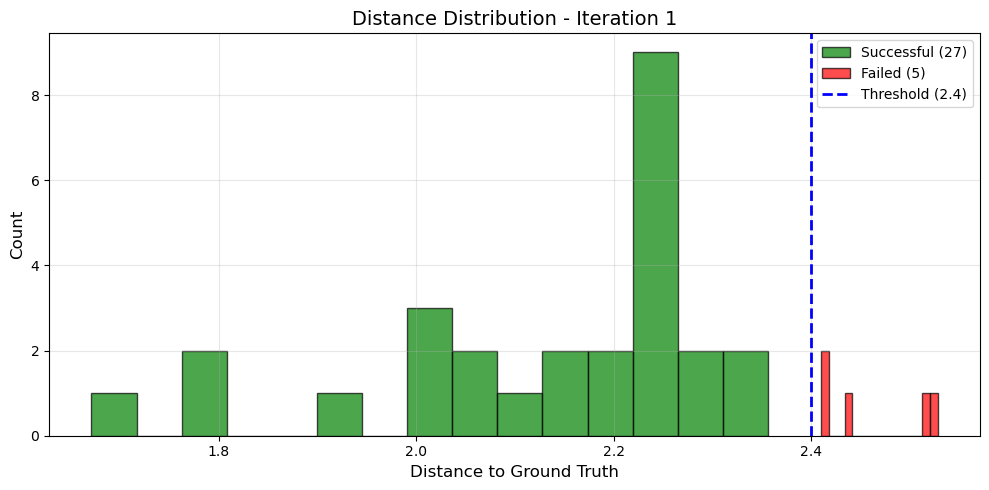

In [16]:
current_iter = simulator.iteration_count

# Get distances from this iteration
success_distances = [r['nearest_distance'] for r in simulator.results._records if r['iteration'] == current_iter]
failed_distances = [fp['nearest_distance'] for fp in simulator.failed_proposals if fp['iteration'] == current_iter]

if success_distances or failed_distances:
    plt.figure(figsize=(10, 5))
    
    if success_distances:
        plt.hist(success_distances, bins=15, alpha=0.7, color='green', 
                 edgecolor='black', label=f'Successful ({len(success_distances)})')
    
    if failed_distances:
        plt.hist(failed_distances, bins=15, alpha=0.7, color='red', 
                 edgecolor='black', label=f'Failed ({len(failed_distances)})')
    
    plt.axvline(CONFIG['distance_threshold'], color='blue', linestyle='--', 
                linewidth=2, label=f'Threshold ({CONFIG["distance_threshold"]})')
    
    plt.xlabel('Distance to Ground Truth', fontsize=12)
    plt.ylabel('Count', fontsize=12)
    plt.title(f'Distance Distribution - Iteration {current_iter}', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No data to plot yet. Run an iteration first.")

## Overall Progress Summary

In [47]:
simulator.print_summary()

# Energy statistics
if len(simulator.results) > 0:
    all_energies = [r['energy'] for r in simulator.results._records]
    print(f"\nEnergy Statistics:")
    print(f"  Best found: {min(all_energies):.4f} eV")
    print(f"  Worst found: {max(all_energies):.4f} eV")
    print(f"  Mean: {np.mean(all_energies):.4f} eV")
    print(f"\n  Ground truth minimum: {ground_truth.energies.min():.4f} eV")
    print(f"  Found global minimum? {min(all_energies) <= ground_truth.energies.min() + 0.001}")


SIMULATION SUMMARY
Iterations completed: 1
Total proposals: 50
Successful discoveries: 26 (52.0%)
Failed proposals: 8
Unique states discovered: 56/419 (13.4% coverage)
Current pool size: 56


Energy Statistics:
  Best found: -10012.5516 eV
  Worst found: -10003.5722 eV
  Mean: -10009.0408 eV

  Ground truth minimum: -10012.6360 eV
  Found global minimum? False


## Export Results (Optional)

In [48]:
# Uncomment to save results
# simulator.export_results("simulation_results.json")